In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,OrdinalEncoder
import warnings
warnings.filterwarnings(action='ignore')

In [ ]:
datasets = ['tips', 'diamonds', 'fmri']
dfs = [sns.load_dataset(name) for name in datasets]

# Data Preprocessing

In [5]:
def compute_dtype(df):
    return df.dtypes
def compute_nunique(df):
    return df.nunique()
def compute_null_percentage(df):
    return (df.isnull().mean() * 100)

In [6]:
def numerical_data(df):
    return df.select_dtypes(include=['number']).columns

In [7]:
def categorical_data(df, threshold = 5):
    return [feature for feature in df.columns
          if df[feature].nunique()<=threshold ]

In [8]:
def str_data(df):
    return df.select_dtypes(include=['object']).columns

In [9]:
#Used for categorical variables.
def fill_na_mode(df):
    str_col=str_data(df)
    for feature in str_col:
        mode=df[feature].mode()[0]
        df[feature].fillna(mode, inplace=True)
    return df

In [10]:
#Better for skewed distributions or data with outliers.
def fill_na_median(df):
    numerical_col=numerical_data(df)
    for feature in numerical_col:
        median=df[feature].median()
        df[feature].fillna(median, inplace=True)
    return df

In [11]:
#Suitable for symmetric (normal) distributions without outliers.
def fill_na_mean(df):
    numerical_col=numerical_data(df)
    for feature in numerical_col:
        mean=df[feature].mean()
        df[feature].fillna(mean, inplace=True)
    return df

In [12]:
def is_null(df):
    return df.isnull().sum()

In [13]:
def drop_null_all_row(df):
    df.dropna(how='any',inplace=True)
    return df

In [14]:
def drop_null_row(df,columns):
    df.dropna(subset=[columns],inplace=True)
    return df

In [15]:
def is_duplicate(df):
    return df.duplicated().sum()

In [16]:
def remove_duplicate(df):
    df.drop_duplicates(inplace = True) 

# EDA

In [17]:
def plot_hist(df,x,xlabel,title,palette):
    plt.figure(figsize=(12, 2))
    sns.histplot(df[x], palette=palette)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Freq')
    plt.show()

In [18]:
def plot_bar(df,x,y,title,palette):
    plt.figure(figsize=(12, 2))
    sns.barplot(x=x,y=y,data=df,palette=palette)
    plt.title(title)
    plt.show()

In [19]:
def plot_pie(df,x,xlabel,ylabel,title,palette):
    plt.figure(figsize=(12, 2))
    plt.pie(df[x].unique(),labels=df[x].unique(),autopct="%1.1f%%", palette=palette)
    plt.title(title)
    plt.show()

In [20]:
def plot_box(df,x,palette):
    plt.figure(figsize=(12, 2))
    sns.boxplot(x=x, data=df, palette=palette)
    plt.title('Box Plot')
    plt.show()

In [ ]:
def plot_scatter(x,y,z,xlabel,ylabel,palette):
    plt.figure(figsize=(12, 2))
    sns.scatterplot(x=x, y=y,hue=z, palette=palette)
    plt.title('Scatter Plot')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# Feature Engineering 

## 1.Numerical Feature Engineering 

### 1.1 Scalling

#### 1.1.1 Normalization 

##### Min-Max Scaling

In [21]:
def mm_scaler(df):
    numerical_col=numerical_data(df)
    scaler=MinMaxScaler()
    for feature in numerical_col:
        df[feature]=scaler.fit_transform(df[[feature]])
    return df 

##### Log normalization

In [22]:
def log_normal(df):
    numerical_col=numerical_data(df)
    for feature in numerical_col:
        negative_feature = df[feature] < 0
        df[feature] = np.log1p(np.abs(df[feature]))
        df[feature]=np.where(negative_feature,-df[feature],df[feature])
    return df 

#### 1.1.2 Standardization 

##### Z-Score Scaling

In [23]:
def z_scaler(df):
    numerical_col=numerical_data(df)
    scaler=StandardScaler()
    for feature in numerical_col:
        df[feature]=scaler.fit_transform(df[[feature]])
    return df 

### 1.2 Discretization

In [24]:
def bin_numerical_features(df, bins=10):
    numerical_col = numerical_data(df)
    for feature in numerical_col:
        df[feature + '_binned'] = pd.cut(df[feature], bins=bins, labels=False)
    return df

### 1.3 Descriptive Feature

#### 1.3.1 Skewness

In [25]:
#Positive Skew-->(mean > median)
#Negative Skew-->(mean < median)
#Zero Skewness-->Symmetrical distribution (mean ≈ median) Normal distribution 

In [26]:
#Log or Square Root Transformation (Best for Right Skew)
#Squaring (Best for Negative Skew)
def skewness(df):
    numerical_col=numerical_data(df)
    df_skew=df[numerical_col].apply(lambda x:x.skew())
    df_skew = df_skew.sort_values(ascending=False)
    df_skew=df_skew.reset_index()
    df_skew.columns = ['Feature', 'SkewFactor']
    return df_skew

#### 1.2.3 Quantile and Precentiles

In [27]:
def quartiles(df):
    numerical_cols = numerical_data(df)
    return df[numerical_cols].quantile([0.25, 0.5, 0.75]).T

#### 1.3 Feature Transformation

In [28]:
def sqrt_transform(df):
    numerical_col=numerical_data(df)
    for feature in numerical_col:
        df[feature] = np.sqrt(df[feature])
    return df 

In [29]:
def sq_transform(df):
    numerical_col=numerical_data(df)
    for feature in numerical_col:
        df[feature] = np.square(df[feature])
    return df 

In [30]:
def correlation(df,target):
    numerical_col=numerical_data(df)
    correlation_matrix = df[numerical_col].corr()
    correlation_target=correlation_matrix[target].sort_values(ascending=False)
    correlation_target=correlation_target.reset_index()
    correlation_target.columns=['feature','corr factor']
    return correlation_target

## 2.Categorical Feature Engineering

#### One-Hot Encoding.

In [ ]:

def one_hot_encoding(df):
    str_col=categorical_data(df)
    df=pd.get_dummies(df,columns=str_col)
    return df

#### Label Encoding

In [32]:
def label_encoding(df):
    str_col=categorical_data(df)
    encoder=LabelEncoder()
    for feature in str_col:
        df[feature]=encoder.fit_transform(df[[feature]])
    return df

#### Ordinal Encoding

In [33]:
def ordinal_encode(df,str_col):
    encoder = OrdinalEncoder()
    df[str_col] = encoder.fit_transform(df[[str_col]])
    return df

# Data : tips

In [35]:
tips=dfs[0].copy()

In [36]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [37]:
tips.shape

(244, 7)

In [38]:
print('Type of Each Feature is''\n',compute_dtype(tips))

Type of Each Feature is
 total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object


In [39]:
print('number of Unique variable in each Feature is''\n',compute_nunique(tips))

number of Unique variable in each Feature is
 total_bill    229
tip           123
sex             2
smoker          2
day             4
time            2
size            6
dtype: int64


In [40]:
print('Number of Nulls in each Feature is ''\n',is_null(tips))

Number of Nulls in each Feature is 
 total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


In [41]:
print('Number of Duplicates in Data ''\n',is_duplicate(tips))

Number of Duplicates in Data 
 1


In [42]:
#handle duplicates
remove_duplicate(tips)

In [43]:
print(f'Number of Numerical Feature is {len(numerical_data(tips))}''\n')
print('Numerical Feature',numerical_data(tips))

Number of Numerical Feature is 3

Numerical Feature Index(['total_bill', 'tip', 'size'], dtype='object')


In [44]:
print(f'Number of Categorical Feature is {len(categorical_data(tips))}''\n')
print('Categorical Feature',categorical_data(tips))

Number of Categorical Feature is 4

Categorical Feature ['sex', 'smoker', 'day', 'time']


In [45]:
print(f'Number of String Feature is {len(str_data(tips))}''\n')
print('String Feature',str_data(tips))

Number of String Feature is 0

String Feature Index([], dtype='object')


In [46]:
print('Skewness in Each Feature is''\n', skewness(tips))

Skewness in Each Feature is
       Feature  SkewFactor
0         tip    1.459802
1        size    1.441613
2  total_bill    1.127363


In [47]:
print('correlation of each Feature Before Transformation''\n',correlation(tips,'total_bill'))

correlation of each Feature Before Transformation
       feature  corr factor
0  total_bill     1.000000
1         tip     0.674998
2        size     0.597589


<Figure size 800x500 with 0 Axes>

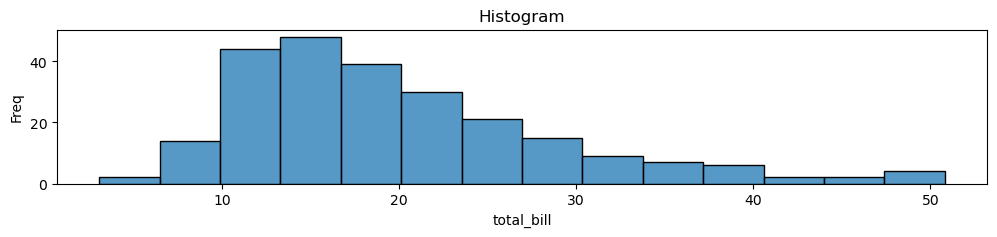

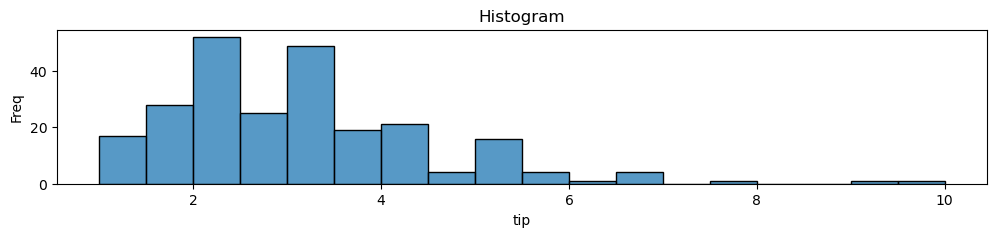

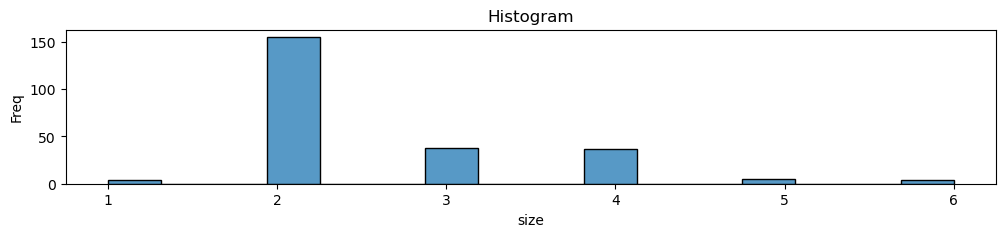

In [48]:
plt.figure(figsize=(8,5))
for i,feature in enumerate(numerical_data(tips)):
    plot_hist(tips,feature,f'{feature}','Histogram','plasma')

In [49]:
print(f'Feature Transformation ',log_normal(tips))

Feature Transformation       total_bill       tip     sex smoker   day    time      size
0      2.889816  0.698135  Female     No   Sun  Dinner  1.098612
1      2.428336  0.978326    Male     No   Sun  Dinner  1.386294
2      3.091497  1.504077    Male     No   Sun  Dinner  1.386294
3      3.205993  1.460938    Male     No   Sun  Dinner  1.098612
4      3.242202  1.528228  Female     No   Sun  Dinner  1.609438
..          ...       ...     ...    ...   ...     ...       ...
239    3.402197  1.934416    Male     No   Sat  Dinner  1.386294
240    3.338613  1.098612  Female    Yes   Sat  Dinner  1.098612
241    3.164208  1.098612    Male    Yes   Sat  Dinner  1.098612
242    2.934920  1.011601    Male     No   Sat  Dinner  1.098612
243    2.984671  1.386294  Female     No  Thur  Dinner  1.098612

[243 rows x 7 columns]


In [50]:
print('Skewness in Each Feature is''\n', skewness(tips))

Skewness in Each Feature is
       Feature  SkewFactor
0        size    0.937031
1         tip    0.373500
2  total_bill   -0.018400


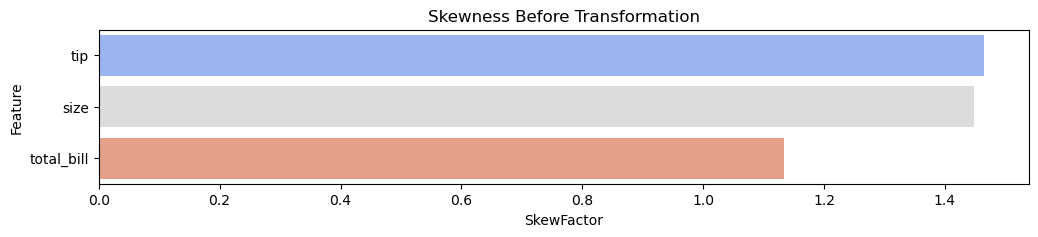

In [51]:
plot_bar(skewness(dfs[0]),x='SkewFactor',y='Feature',title='Skewness Before Transformation',palette='coolwarm')

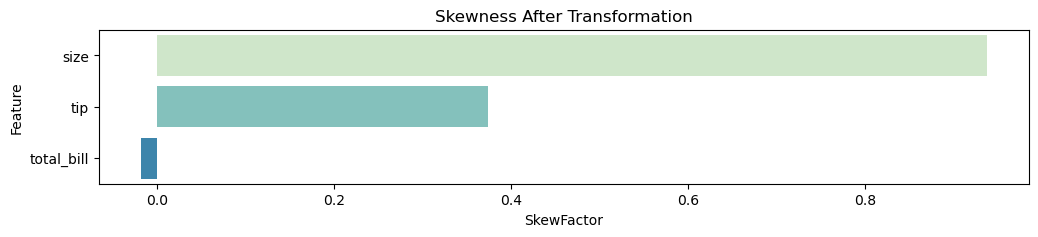

In [52]:
plot_bar(skewness(tips),x='SkewFactor',y='Feature',title='Skewness After Transformation',palette='GnBu')

In [53]:
print('correlation of each Feature After Transformation''\n',correlation(tips,'total_bill'))

correlation of each Feature After Transformation
       feature  corr factor
0  total_bill     1.000000
1         tip     0.678379
2        size     0.612536


In [54]:
label_encoding(tips)

,total_bill,tip,sex,smoker,day,time,size
0,2.889816,0.698135,0,0,2,0,1.098612
1,2.428336,0.978326,1,0,2,0,1.386294
2,3.091497,1.504077,1,0,2,0,1.386294
3,3.205993,1.460938,1,0,2,0,1.098612
4,3.242202,1.528228,0,0,2,0,1.609438
...,...,...,...,...,...,...,...
239,3.402197,1.934416,1,0,1,0,1.386294
240,3.338613,1.098612,0,1,1,0,1.098612
241,3.164208,1.098612,1,1,1,0,1.098612
242,2.934920,1.011601,1,0,1,0,1.098612


In [55]:
one_hot_encoding(dfs[0])

,total_bill,tip,size,sex_Male,sex_Female,smoker_Yes,smoker_No,day_Thur,day_Fri,day_Sat,day_Sun,time_Lunch,time_Dinner
0,16.99,1.01,2,False,True,False,True,False,False,False,True,False,True
1,10.34,1.66,3,True,False,False,True,False,False,False,True,False,True
2,21.01,3.50,3,True,False,False,True,False,False,False,True,False,True
3,23.68,3.31,2,True,False,False,True,False,False,False,True,False,True
4,24.59,3.61,4,False,True,False,True,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,3,True,False,False,True,False,False,True,False,False,True
240,27.18,2.00,2,False,True,True,False,False,False,True,False,False,True
241,22.67,2.00,2,True,False,True,False,False,False,True,False,False,True
242,17.82,1.75,2,True,False,False,True,False,False,True,False,False,True


In [56]:
bin_numerical_features(tips)

,total_bill,tip,sex,smoker,day,time,size,total_bill_binned,tip_binned,sex_binned,smoker_binned,day_binned,time_binned,size_binned
0,2.889816,0.698135,0,0,2,0,1.098612,5,0,0,0,6,0,3
1,2.428336,0.978326,1,0,2,0,1.386294,4,1,9,0,6,0,5
2,3.091497,1.504077,1,0,2,0,1.386294,6,4,9,0,6,0,5
3,3.205993,1.460938,1,0,2,0,1.098612,7,4,9,0,6,0,3
4,3.242202,1.528228,0,0,2,0,1.609438,7,4,0,0,6,0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,3.402197,1.934416,1,0,1,0,1.386294,7,7,9,0,3,0,5
240,3.338613,1.098612,0,1,1,0,1.098612,7,2,0,9,3,0,3
241,3.164208,1.098612,1,1,1,0,1.098612,6,2,9,9,3,0,3
242,2.934920,1.011601,1,0,1,0,1.098612,6,1,9,0,3,0,3


In [57]:
correlation(tips,'total_bill')

,feature,corr factor
0,total_bill,1.000000
1,total_bill_binned,0.982753
2,tip,0.678379
3,tip_binned,0.668875
4,size,0.612536
5,size_binned,0.612498
6,sex_binned,0.149445
7,sex,0.149445
8,smoker_binned,0.061847
9,smoker,0.061847


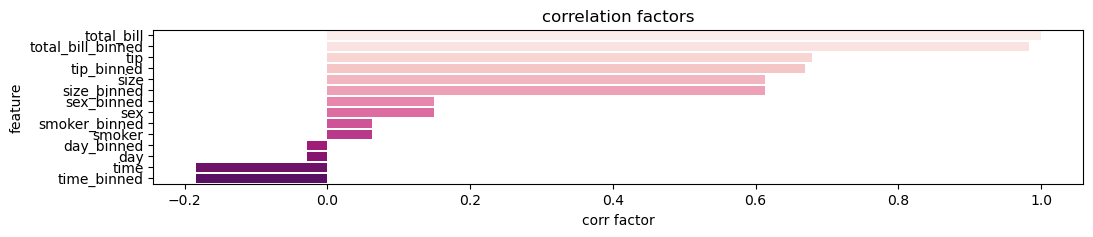

In [58]:
plot_bar(correlation(tips,'total_bill'),'corr factor','feature','correlation factors','RdPu' )